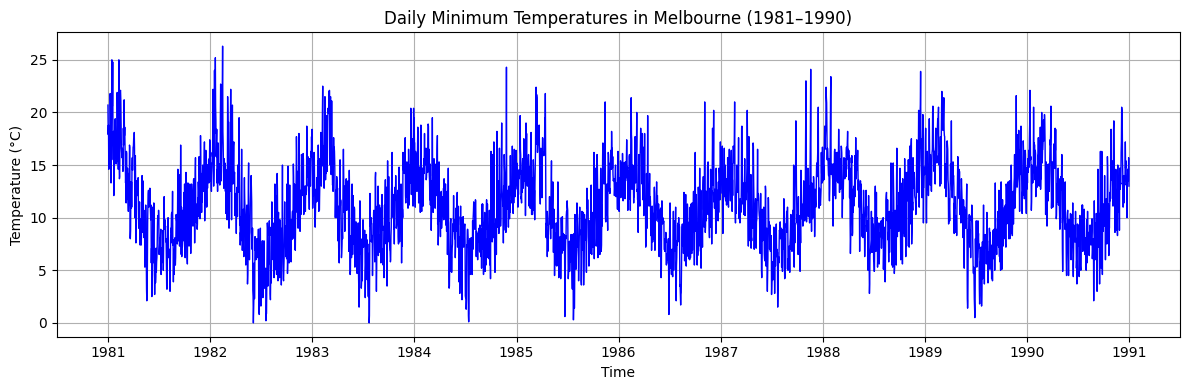

In [5]:
#1. Line Plot
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv")

# Convert 'Date' to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Set date as index
df.set_index('Date', inplace=True)

# Line plot
plt.figure(figsize=(12, 4))
plt.plot(df['Temp'], color='blue', linewidth=1)
plt.title('Daily Minimum Temperatures in Melbourne (1981–1990)')
plt.xlabel('Time')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.tight_layout()
plt.show()


<Figure size 1200x1000 with 0 Axes>

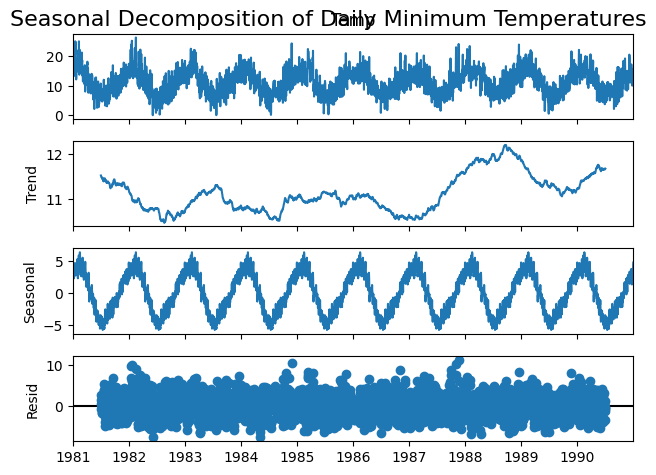

In [6]:
#2. Seasonal Decomposition
# Seasonal Decomposition of Time Series
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Load and prepare the data
df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Apply seasonal decomposition (Additive Model)
decomposition = seasonal_decompose(df['Temp'], model='additive', period=365)

# Extract components
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Plot the components
plt.figure(figsize=(12, 10))
decomposition.plot()
plt.suptitle('Seasonal Decomposition of Daily Minimum Temperatures', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()



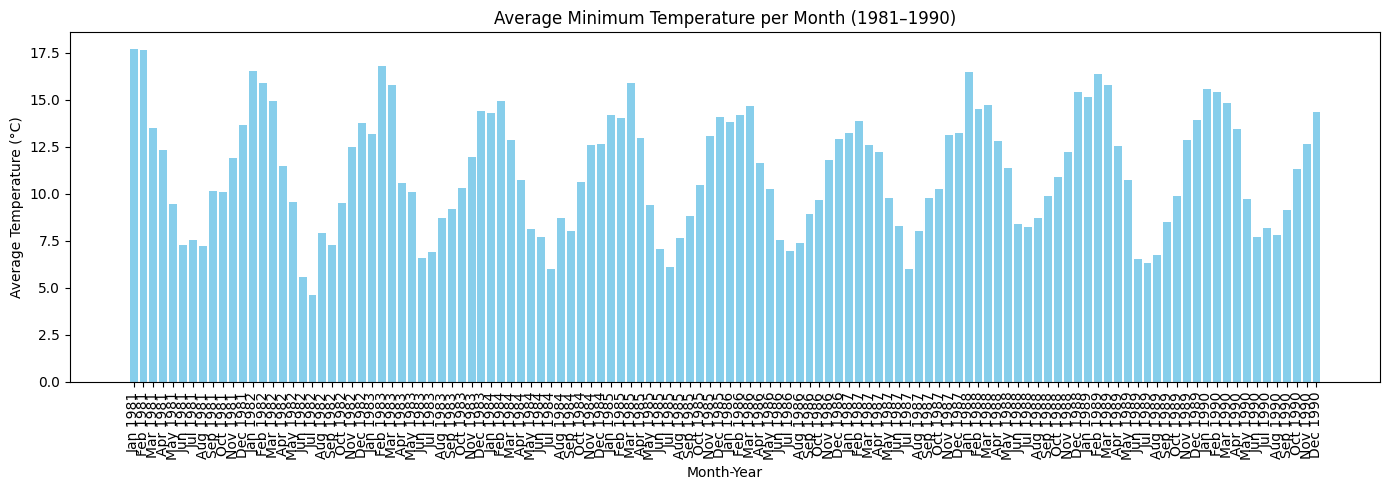

In [9]:
#3. Bar Chart
# 3. Bar Chart - Average Monthly Minimum Temperature
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset and prepare datetime index
df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Group by month-end and calculate average temperature
monthly_avg = df['Temp'].resample('ME').mean()  # Use 'ME' instead of deprecated 'M'

# Extract month-year labels
month_names = monthly_avg.index.strftime('%b %Y')

# Plot bar chart
plt.figure(figsize=(14, 5))
plt.bar(month_names, monthly_avg, color='skyblue')
plt.xticks(rotation=90)
plt.title('Average Minimum Temperature per Month (1981–1990)')
plt.xlabel('Month-Year')
plt.ylabel('Average Temperature (°C)')
plt.tight_layout()
plt.show()



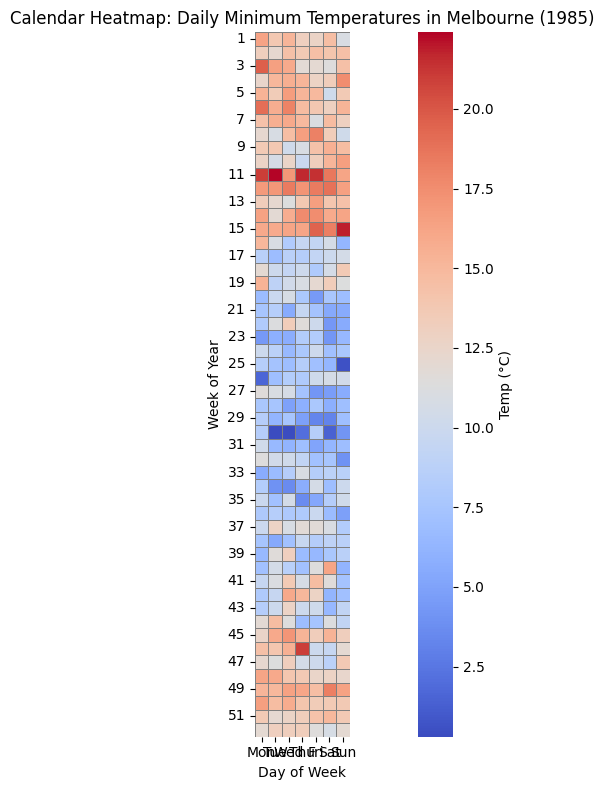

In [13]:
#4. Calendar Heatmap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data and prepare
df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Filter data for 1985 using .loc
df_1985 = df.loc['1985'].copy()

# Add week and weekday columns
df_1985['Week'] = df_1985.index.isocalendar().week
df_1985['Weekday'] = df_1985.index.weekday

# Handle ISO week 53 (rare)
df_1985.loc[df_1985['Week'] == 53, 'Week'] = 0

# Aggregate temperatures by week and weekday to avoid duplicates
heatmap_data = df_1985.groupby(['Week', 'Weekday'])['Temp'].mean().unstack()

# Plotting
plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, cmap='coolwarm', linewidths=0.5, linecolor='gray',
            cbar_kws={'label': 'Temp (°C)'}, square=True)

plt.title('Calendar Heatmap: Daily Minimum Temperatures in Melbourne (1985)')
plt.xlabel('Day of Week')
plt.ylabel('Week of Year')
plt.xticks(ticks=[0.5 + i for i in range(7)], labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



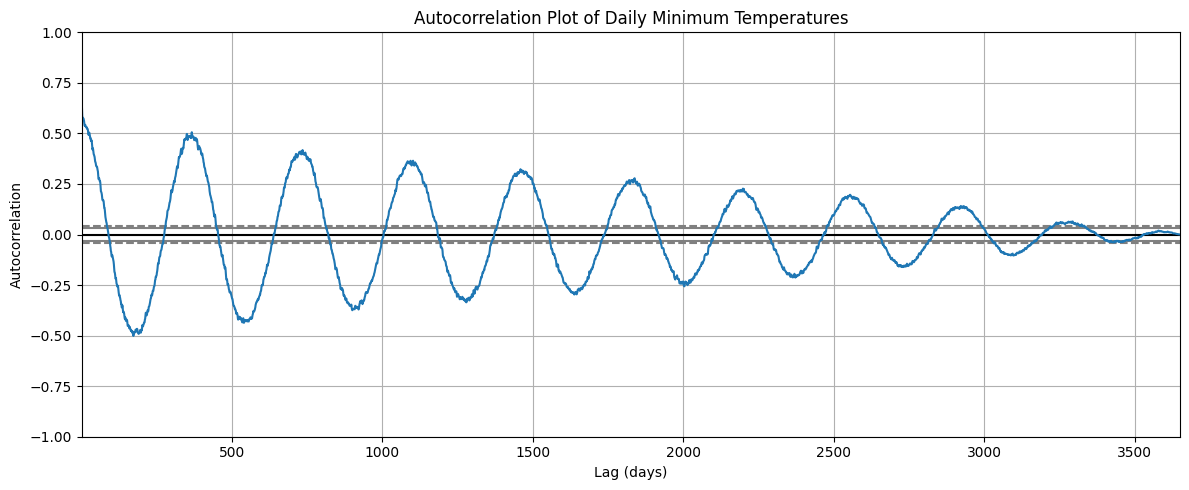

In [14]:
#5. Autocorrelation Plot
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import autocorrelation_plot

# Load dataset and prepare datetime index
df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Plot autocorrelation
plt.figure(figsize=(12, 5))
autocorrelation_plot(df['Temp'])
plt.title('Autocorrelation Plot of Daily Minimum Temperatures')
plt.xlabel('Lag (days)')
plt.ylabel('Autocorrelation')
plt.tight_layout()
plt.show()


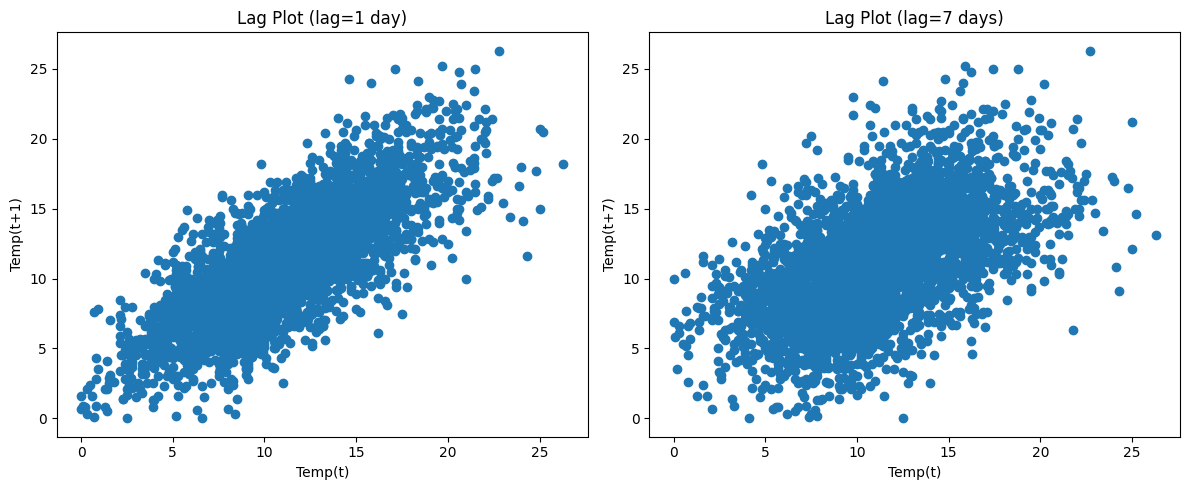

In [15]:
#6. Lag Plot
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import lag_plot

# Load data
df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Create subplots for lag-1 and lag-7
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
lag_plot(df['Temp'], lag=1)
plt.title('Lag Plot (lag=1 day)')
plt.xlabel('Temp(t)')
plt.ylabel('Temp(t+1)')

plt.subplot(1, 2, 2)
lag_plot(df['Temp'], lag=7)
plt.title('Lag Plot (lag=7 days)')
plt.xlabel('Temp(t)')
plt.ylabel('Temp(t+7)')

plt.tight_layout()
plt.show()
